<center>
<small>
Nova Information Management School<br>
Bachelor in Data Science, 2025-26<br>
Machine Learning I<br><br>
Project developed by Group 7<br>
Carolina Arez 20241739 · Henrique Madureira 20241756 · Miguel Melo 20241757 · Noa Penas 20241682
</small>
</center>

<hr style="border: 0.5px solid #E89C63;">

# <font color='#E89C63'>Notebook 1: Data Exploration </font> <a class="anchor" id="P0"></a>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
In this notebook, we perform an <strong>exploratory data analysis</strong> on the Nata Visionaries dataset.
</div>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
The <strong>goal</strong> is to understand the characteristics of the features that describe each Pastel de Nata production, identify patterns related to the target variable <code style="font-size:14px;">quality_class</code>, and detect any data quality issues.<br>

<br>
To make it easier to identify what is being done in each code block, we will formulate each step as a <strong>task or action</strong>.
<br>
<br>
Below is a <strong>table of contents</strong> to make navigation easier across the different sections of the notebook.
</div>
<br>

### <font color='#E89C63'>Table of Contents </font> <a class="anchor" id="P0"></a>
- [1. Business Understanding](#P1)

- [2. Data Understanding](#P2)
    - [Analysis: Data Dictionary Overview](#P3)
    - [Analysis: `Learn` dataset ](#P4)
      - [Missing Values and Inconsistencies](#P5)
      - [Statistical Summary Observations (Numerical Features)](#P6)
      - [Statistical Summary Observations (Categorical Features)](#P7)
    - [Analysis: `Predict` dataset](#P8)
      - [Missing Values and Inconsistencies](#P9)
      - [Statistical Summary Observations (Numerical Features)](#P10)
      - [Statistical Summary Observations (Categorical Features)](#11)
    - [Analyis: Observations and Data Cleaning Plan](#P12)
      - [Categorical Columns](#P13)
      - [Numerical Columns](#P14)
      - [Irrelevant Columns](#15)
      - [Conclusion](#16)
    - [Analysis: Media, Median and Outliers](#P17)
      - [Multivariate Outlier Detection: Baking Duration vs. Oven Temperature](#18)
    - [Analysis: Skewed Distributions](#P19)
    - [Handling: Missing Values and Outliers](#P20)
    - [Analysis: Correlations of Numerical Features with the Target Variable ](#21)
    - [Analysis: Correlation Analysis of Numerical Features (Excluding Target) ](#P22)

### <font color='#E89C63'>1. Business Understanding: *In crust we trust*. </font> <a class="anchor" id="P1"></a>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
<strong>Objective</strong>: Develop a model to classify pastries as OK or KO based on baking and ingredient data.
</div>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
<ul style="margin:0; padding-left:20px;">
    <li><strong>OK</strong> (good quality)</li>
    <li><strong>KO</strong> (poor quality)</li>
</ul>
</div>

### <font color='#E89C63'>2. Data understanding: *The path to wisdom is dusted with cinnamon*. </font> <a class="anchor" id="P2"></a>

**2.1.** Import the libraries.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<br>

**2.2.** Load the training data stored in `learn.csv` and the prediction data stored in `predict.csv` into pandas DataFrames, set the `id` column as the index.

In [2]:
learn = pd.read_csv('Nata_Files/learn.csv', index_col=0)
predict = pd.read_csv('Nata_Files/predict.csv', index_col=0)

In [3]:
pd.read_csv('Nata_Files/data_dictionary.csv', index_col=0)

,Type,Description,Unit
Feature,,,
id,Numeric,Internal identifier for each record,-
ambient_humidity,Numeric,Kitchen ambient humidity during baking,%
baking_duration,Numeric,Total baking time at high temperature,minutes
cooling_period,Numeric,Resting time after baking before removal,minutes
cream_fat_content,Numeric,Fat percentage in cream used,%
egg_temperature,Numeric,Temperature of eggs when added to custard,°C
egg_yolk_count,Numeric,Number of egg yolks per batch,count
final_temperature,Numeric,Measured temperature at end of baking,°C
lemon_zest_ph,Numeric,pH of lemon zest infusion in custard,pH scale


---
#### <strong> <font color='#E89C63'> Analysis: Data Dictionary Overview </font> <a class="anchor" id="P3"></a> </strong>
---
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The datasets include information on <strong>process, ingredients, and outcomes</strong>.

<ul>
<li><strong>Identifier variable</strong>: <code>id</code> uniquely identifies each record;</li>
<li><strong>Time variables</strong>: (<code>baking_duration</code>, <code>cooling_period</code>, <code>preheating_time</code>) are in minutes;</li>
<li><strong>Temperature variables</strong>: (<code>egg_temperature</code>, <code>oven_temperature</code>, <code>final_temperature</code>) are in °C;</li>
<li><strong>Ingredient variables</strong>: (<code>cream_fat_content</code>, <code>egg_yolk_count</code>, <code>vanilla_extract</code>, <code>lemon_zest_ph</code>, <code>sugar_content</code>, <code>salt_ratio</code>) capture the composition of the recipe. Adjusting <code>salt_ratio</code> units to align with <code>sugar_content</code> could make comparisons easier;</li>
<li><strong>Other numeric variables</strong>: <code>ambient_humidity</code> (%) measures kitchen humidity during baking.</li>
</ul>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong>Categorical variables:</strong>
<ul>
<li><code>origin</code>: Porto or Lisboa;</li>
<li><code>pastry_type</code>: types of pastries recorded, only <strong>Pastel de Nata</strong> is relevant for analysis;</li>
<li><code>quality_class</code>: OK or KO.</li>
</ul>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong>Text variable:</strong>
<ul>
<li><code>notes_baker</code> provides additional information from the baker.</li>
</ul>
</div>


---
#### <strong> <font color='#E89C63'>  Analysis: `Learn` dataset </font> <a class="anchor" id="P4"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
We begin by exploring the <code>learn</code> dataset to understand its structure and contents. We first <strong>examine the first five rows</strong> to see how the data is organized, then review the <strong>variable types, missing values, and summary statistics</strong> for both numerical and categorical features. This provides a clear overview of the dataset before moving on to further analysis.
</div>


In [4]:
display(learn.head())
display(learn.info())
display(learn.describe().T)
display(learn.describe(include='object').T)

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract,quality_class
id,,,,,,,,,,,,,,,,,
1,54.0,24.0,26.0,100.4,52.0,11.0,309.0,3.2,NaN,Lisboa,NaN,Pastel Nata,207.0,42.74,22.8,5.7,KO
2,66.0,37.0,34.0,98.0,46.0,10.0,317.0,3.3,NaN,Lisboa,306.0,NaN,245.0,41.73,11.6,4.0,KO
3,41.0,30.0,19.0,99.3,53.0,10.0,130.0,3.4,NaN,Porto,121.0,NaN,186.0,75.10,20.3,7.5,OK
4,62.0,24.0,48.0,98.0,115.0,9.0,354.0,3.3,NaN,Lisboa,357.0,Pastel de Nata,186.0,46.41,73.3,4.2,OK
5,55.0,21.0,34.0,100.1,48.0,9.0,211.0,3.0,NaN,Lisboa,202.0,Pastel de nata,218.0,56.52,80.1,6.0,KO


<class 'pandas.core.frame.DataFrame'>
Index: 5200 entries, 1 to 5200
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ambient_humidity   5182 non-null   float64
 1   baking_duration    5199 non-null   float64
 2   cooling_period     5199 non-null   float64
 3   cream_fat_content  5176 non-null   float64
 4   egg_temperature    5176 non-null   float64
 5   egg_yolk_count     5176 non-null   float64
 6   final_temperature  5175 non-null   float64
 7   lemon_zest_ph      5174 non-null   float64
 8   notes_baker        0 non-null      float64
 9   origin             5039 non-null   object 
 10  oven_temperature   5179 non-null   float64
 11  pastry_type        3411 non-null   object 
 12  preheating_time    5181 non-null   float64
 13  salt_ratio         5187 non-null   float64
 14  sugar_content      5178 non-null   float64
 15  vanilla_extract    5182 non-null   float64
 16  quality_class      5199 non-n

None

,count,mean,std,min,25%,50%,75%,max
ambient_humidity,5182.0,59.980316,11.616151,40.00,50.00,60.00,70.000,80.00
baking_duration,5199.0,26.979804,8.320079,14.00,21.00,25.00,30.000,89.00
cooling_period,5199.0,31.817850,14.427143,0.00,25.00,31.00,39.000,105.00
cream_fat_content,5176.0,98.413060,1.997350,91.90,97.10,98.40,99.800,107.30
egg_temperature,5176.0,70.812403,35.439831,12.00,44.00,67.00,92.000,575.00
egg_yolk_count,5176.0,10.498068,1.257709,8.00,10.00,10.00,11.000,15.00
final_temperature,5175.0,223.577198,85.258779,31.00,164.00,226.00,284.000,722.00
lemon_zest_ph,5174.0,3.218902,0.165909,2.70,3.10,3.20,3.300,4.00
notes_baker,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oven_temperature,5179.0,223.541031,84.482034,58.00,166.00,227.00,283.000,713.00


,count,unique,top,freq
origin,5039,10,Lisboa,3486
pastry_type,3411,4,Pastel Nata,879
quality_class,5199,2,OK,3302


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The dataset contains <strong>5200 records</strong> and <strong>17 columns</strong>, including numerical, categorical, and text features. The data captures baking conditions, ingredient characteristics, and pastry quality classifications.

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> 1. Missing Values and Inconsistencies </font> <a class="anchor" id="P5"></a> </strong>
  <ul>
    <li><code>notes_baker</code> has <strong>all 5200 entries missing</strong>, making it unusable for analysis;</li>
    <li><code>pastry_type</code> has <strong>1789 missing entries</strong>, which is significant and may bias analyses if not handled;</li>
    <li>Other features have minor missing values (21–161 missing), including <code>origin</code>, <code>cream_fat_content</code>, <code>egg_temperature</code>, <code>egg_yolk_count</code>, <code>final_temperature</code>, <code>lemon_zest_ph</code>, and <code>oven_temperature</code>;</li>
    <li>The target variable <code>quality_class</code> has only <strong>1 missing entry</strong>.</li>
  </ul>
</div>
<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong> <font color='#E89C63'> 2. Statistical Summary Observations (Numerical Features) </font> <a class="anchor" id="P6"></a> </strong>
<br>
<br>
The numerical features show some notable observations and extreme values that require attention:
<ul>
<li><code>egg_temperature</code> max: <strong>575°C</strong> (unrealistic for eggs);</li>
<li><code>final_temperature</code> max: <strong>722°C</strong>;</li>
<li><code>oven_temperature</code> max: <strong>713°C</strong>;</li>
<li><code>cream_fat_content</code> has a few values slightly above 100% (max <strong>107.30%</strong>), which is physically impossible and should be corrected or capped;</li>
<li><code>salt_ratio</code> max: <strong>640.32 g/kg</strong>;</li>
<li><code>sugar_content</code> max: <strong>656.50 g/100g</strong> (physically impossible, likely due to errors or misreported units);
  <ul>
    <li>The <code>sugar_content</code> values above 100 g/100g will need to be capped or corrected, since concentrations cannot exceed 100 g per 100 g of product.</li>
  </ul>
</li>
<li>Mean and median values are close for most features, but outliers suggest the need for <strong>data cleaning or capping</strong>.</li>
</ul>
</div>
<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong><font color='#E89C63'>3. Statistical Summary Observations (Categorical Features)</font></strong> <a class="anchor" id="P7"></a> </strong>
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Analyzing the table, <code>origin</code> shows <strong>10 unique values</strong>, even though only <strong>Lisboa</strong> and <strong>Porto</strong> are expected. This suggests that these regions were recorded differently for a few rows (e.g., extra spaces, capitalization, or minor inconsistencies).
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Similarly, the <strong>4 types</strong> in <code>pastry_type</code> indicate variations of <em>Pastel Nata</em>.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
For <code>quality_class</code>, only <strong>OK</strong> and <strong>KO</strong> appear as values for our target variable, but there is <strong>one missing value</strong>, which can be safely removed before modeling.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Also, the column <code>notes_baker</code> contains <strong>no data</strong>. Therefore, this column can be safely removed from the dataset in Notebook 2 to avoid unnecessary processing.
</div>
<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Check the <strong>unique values</strong> in the categorical columns, focusing on <code>pastry_type</code> to see if there are any pastries other than “Pastel de Nata” in this dataset:</li>
</ul>
</div>


In [5]:
print("Pastry Type:", learn['pastry_type'].unique())
print("Origin:", learn['origin'].unique())
print("Quality Class:", learn['quality_class'].unique())

Pastry Type: ['Pastel Nata' nan 'Pastel de Nata' 'Pastel de nata' 'Pastel De Nata']
Origin: ['Lisboa' 'Porto' ' Lisboa' 'Porto ' 'LISBOA' 'PORTO' 'lisboa' nan
 'Lisboa ' 'porto' ' Porto']
Quality Class: ['KO' 'OK' nan]


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The dataset contains mainly <code>pastry_type</code> as 'Pastel de Nata' and <code>NaN</code>. There are inconsistencies in capitalization and spacing, e.g., 'Pastel Nata', 'Pastel de Nata', 'Pastel de nata', 'Pastel De Nata'.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
For <code>origin</code>, only 'Lisboa' and 'Porto' are expected (plus <code>NaN</code>), but inconsistencies in formatting appear, such as extra spaces and differences in capitalization (' Lisboa', 'Porto ', 'LISBOA', 'porto').
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The <code>quality_class</code> column contains 'OK', 'KO', and <code>NaN</code>, representing the target variable.
</div>


<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Check the <strong>unique values</strong> in the <code>origin</code> column, making sure to <strong>clean the data first</strong> by removing extra spaces and standardizing capitalization, and then <strong>examine the distribution of records</strong> for each origin, including any missing values:</li>
</ul>
</div>


In [6]:
learn['origin'] = learn['origin'].str.strip().str.title()
print("Origin:", learn['origin'].unique())

Origin: ['Lisboa' 'Porto' nan]


In [7]:
learn['origin'].value_counts(dropna=False)

origin
Lisboa    3796
Porto     1243
NaN        161
Name: count, dtype: int64

<div style="font-size:15px; line-height:1.3;">
The <code>origin</code> column shows an uneven distribution of records: <strong>Lisboa</strong> accounts for the majority with 3796 entries, while <strong>Porto</strong> has 1243 entries.  
There are <strong>161 missing values</strong>, which represent a small portion of the dataset but should still be considered in analysis.  
This distribution indicates a strong bias toward Lisboa, which may affect analyses or models that rely on origin as a feature.
</div>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Since our target variable is <code>quality_class</code>, it's important to have all entries non-null, therefore, we are going to inspect the row that has this missing value:</li>
</ul>
</div>

In [8]:
learn[learn['quality_class'].isna()]

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract,quality_class
id,,,,,,,,,,,,,,,,,
2522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
As the row contains only missing values, we <strong>can safely drop</strong> it in Notebook 2.
</div>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Check if there are any other rows containing only missing values besides the row with index 2522:</li>
</ul>
</div>



In [9]:
learn[learn.isnull().all(axis=1)]

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract,quality_class
id,,,,,,,,,,,,,,,,,
2522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong>No other rows</strong> contain only missing values apart from 2522.</li>
</div>


<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Since duplicate rows (ignoring the ID column) can cause redundancy and inflate data processing, check if <strong>rows with the same values are duplicated</strong> in this dataset:</li>
</ul>
</div>

In [10]:
duplicate_rows_learn = learn[learn.duplicated(keep=False)]
duplicate_rows_learn

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract,quality_class
id,,,,,,,,,,,,,,,,,
1,54.0,24.0,26.0,100.4,52.0,11.0,309.0,3.2,NaN,Lisboa,NaN,Pastel Nata,207.0,42.74,22.8,5.7,KO
1525,54.0,24.0,26.0,100.4,52.0,11.0,309.0,3.2,NaN,Lisboa,NaN,Pastel Nata,207.0,42.74,22.8,5.7,KO
2917,65.0,40.0,49.0,97.5,30.0,10.0,122.0,3.1,NaN,Porto,112.0,NaN,346.0,81.01,26.3,6.1,OK
3503,65.0,40.0,49.0,97.5,30.0,10.0,122.0,3.1,NaN,Porto,112.0,NaN,346.0,81.01,26.3,6.1,OK


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In the final dataset, since rows 1 and 1525, and rows 2917 and 3503, are duplicated apart from the ID column, <strong>we will retain only one row from each</strong> in Notebook 2.
</div>
<br>

---
####  <strong> <font color='#E89C63'>  Analysis: `Predict` dataset </font> <a class="anchor" id="P8"></a> </strong>
---
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Next, we are going to explore the <code>predict</code> dataset. The dataset does not include the <code>quality_class</code> labels, so our focus is on understanding its structure, variable types, and potential missing values. We perform this exploration to check whether it makes sense, in Notebook 9, to apply the same transformations to the <code>predict</code> dataset that we applied to the <code>learn</code> dataset.  
    
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
 <br><strong>For example,</strong> in the <code>learn</code> dataset we found a feature recorded as <code>600g/100g</code>, which was clearly an error. If this error does not appear in the <code>predict</code> dataset, there is no need to apply any specific correction. This step ensures that only relevant and necessary preprocessing is carried out, avoiding unnecessary changes to already correct data.

</div>


In [11]:
display(predict.head())
display(predict.info())
display(predict.describe().T)
display(predict.describe(include='object').T)

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract
id,,,,,,,,,,,,,,,,
5201,79.0,22,40,98.6,79.0,9.0,259.0,3.2,NaN,Lisboa,268.0,NaN,208.0,49.63,182.6,4.0
5202,49.0,26,32,101.9,105.0,9.0,287.0,3.2,NaN,Lisboa,287.0,Pastel de nata,189.0,182.54,76.2,4.8
5203,80.0,28,24,96.6,20.0,10.0,64.0,3.4,NaN,Porto,74.0,Pastel Nata,201.0,100.41,23.5,6.1
5204,74.0,21,37,97.2,81.0,9.0,314.0,3.0,NaN,Lisboa,317.0,NaN,220.0,46.66,143.2,4.9
5205,41.0,19,41,97.3,104.0,10.0,246.0,3.2,NaN,Lisboa,243.0,Pastel Nata,191.0,39.45,143.0,7.0


<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 5201 to 6500
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ambient_humidity   1296 non-null   float64
 1   baking_duration    1300 non-null   int64  
 2   cooling_period     1300 non-null   int64  
 3   cream_fat_content  1295 non-null   float64
 4   egg_temperature    1297 non-null   float64
 5   egg_yolk_count     1296 non-null   float64
 6   final_temperature  1296 non-null   float64
 7   lemon_zest_ph      1296 non-null   float64
 8   notes_baker        0 non-null      float64
 9   origin             1274 non-null   object 
 10  oven_temperature   1294 non-null   float64
 11  pastry_type        849 non-null    object 
 12  preheating_time    1298 non-null   float64
 13  salt_ratio         1297 non-null   float64
 14  sugar_content      1293 non-null   float64
 15  vanilla_extract    1293 non-null   float64
dtypes: float64(12), int64(2), 

None

,count,mean,std,min,25%,50%,75%,max
ambient_humidity,1296.0,60.487654,11.607274,40.00,50.75,60.50,71.00,80.00
baking_duration,1300.0,26.964615,7.993279,14.00,21.00,25.00,30.00,66.00
cooling_period,1300.0,32.058462,15.101748,0.00,25.00,31.00,39.00,149.00
cream_fat_content,1295.0,98.451969,1.976718,91.70,97.10,98.40,99.80,105.50
egg_temperature,1297.0,71.721665,35.579924,12.00,44.00,68.00,94.00,274.00
egg_yolk_count,1296.0,10.493827,1.247066,8.00,9.00,10.00,11.00,14.00
final_temperature,1296.0,224.375772,86.620505,30.00,167.75,227.50,286.00,573.00
lemon_zest_ph,1296.0,3.217593,0.167882,2.70,3.10,3.20,3.30,4.00
notes_baker,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oven_temperature,1294.0,223.755796,86.118189,60.00,165.00,227.50,283.00,568.00


,count,unique,top,freq
origin,1274,10,Lisboa,887
pastry_type,849,4,Pastel de nata,231


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The dataset contains <strong>1300 records</strong> and <strong>16 columns</strong>, including numerical, categorical, and text features. It has the same columns as the <code>learn</code> dataset, except it does not include <code>quality_class</code>, which is our target variable.
</div>


<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong> <font color='#E89C63'> 1. Missing Values and Inconsistencies </font> <a class="anchor" id="P9"></a> </strong>
  <ul>
    <li><code>notes_baker</code> has <strong>all 1300 entries missing</strong>, making it unusable for analysis;</li>
    <li><code>pastry_type</code> has <strong>451 missing entries</strong>, which is significant and may bias analyses if not handled;</li>
    <li>Other features have minor missing values (2–26 missing), including <code>ambient_humidity</code>, <code>cream_fat_content</code>, <code>egg_temperature</code>, <code>egg_yolk_count</code>, <code>final_temperature</code>, <code>lemon_zest_ph</code>, <code>origin</code>, and <code>oven_temperature</code>.</li>
</div>
<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong> <font color='#E89C63'> 2. Statistical Summary Observations (Numerical Features) </font> <a class="anchor" id="10"></a> </strong>
<br>
<br>
The numerical features show some notable observations and extreme values that require attention:
<ul>
<li><code>egg_temperature</code> ranges from 12°C to <strong>274°C</strong>;</li>
<li><code>final_temperature</code> max: <strong>573°C</strong>;</li>
<li><code>oven_temperature</code> max: <strong>568°C</strong>;</li>
<li><code>cream_fat_content</code> has a few values slightly above 100% (max <strong>105.5%</strong>), which is physically impossible and should be corrected or capped;</li>
<li><code>salt_ratio</code> max: <strong>460.12 g/kg</strong>;
<li><code>sugar_content</code> max: <strong>308.3 g/100g</strong> (physically impossible, likely due to errors or misreported units);</li>
<ul>
    <li>The <code>sugar_content</code> values above 100 g/100g will need to be capped or corrected, since concentrations cannot exceed 100 g per 100 g of product, as <strong>also observed</strong> in the <code>learn</code> dataset. </li>
  </ul>    
<li>Other features such as <code>baking_duration</code>, <code>cooling_period</code>, <code>egg_yolk_count</code>, <code>lemon_zest_ph</code>, <code>preheating_time</code>, and <code>vanilla_extract</code> appear within reasonable ranges, with mean and median values generally aligned.</li>
<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<strong><font color='#E89C63'>3. Statistical Summary Observations (Categorical Features)</font></strong> <a class="anchor" id="11"></a>
</div>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Analyzing the table, <code>origin</code> shows <strong>10 unique values</strong>, even though only <strong>Lisboa</strong> and <strong>Porto</strong> are expected. This suggests that these regions were recorded differently for a few rows (e.g., extra spaces, capitalization, or minor inconsistencies), which is also observed in the <code>learn</code> dataset.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Similarly, the <strong>4 types</strong> in <code>pastry_type</code> indicate variations of <em>Pastel Nata</em>, a pattern consistent with the <code>learn</code> dataset.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Also, the column <code>notes_baker</code> contains <strong>no data</strong>. Therefore, this column can be safely removed from the dataset in Notebook 2 to avoid unnecessary processing, as confirmed in the <code>learn</code> dataset.
</div>
<br>

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Verify if the <code>predict</code> dataset has any rows that contain only missing values:</li>
</ul>
</div>

In [12]:
predict.isna().all(axis=1).any()

np.False_

<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>Check the <strong>unique values</strong> in the <code>origin</code> column, making sure to <strong>clean the data first</strong> by removing extra spaces and standardizing capitalization, and then <strong>examine the distribution of records</strong> for each origin, including any missing values:</li>
</ul>
</div>


In [13]:
print("Pastry Type:", predict['pastry_type'].unique())
print("Origin:", predict['origin'].unique())

Pastry Type: [nan 'Pastel de nata' 'Pastel Nata' 'Pastel De Nata' 'Pastel de Nata']
Origin: ['Lisboa' 'Porto' nan 'LISBOA' 'lisboa' 'porto' 'Lisboa ' ' Lisboa'
 'PORTO' 'Porto ' ' Porto']


In [14]:
predict['origin'] = predict['origin'].str.strip().str.title()
print("Origin:", predict['origin'].unique())

Origin: ['Lisboa' 'Porto' nan]


In [15]:
predict['origin'].value_counts(dropna=False)

origin
Lisboa    964
Porto     310
NaN        26
Name: count, dtype: int64

<div style="font-size:15px; line-height:1.3;">
The <code>origin</code> column shows an uneven distribution of records: <strong>Lisboa</strong> accounts for the majority with 964 entries, while <strong>Porto</strong> has 310 entries.  
There are <strong>26 missing values</strong>, which represent a small portion of the dataset but should still be considered in analysis.  
This distribution indicates a strong bias toward Lisboa, which may affect analyses or models that rely on origin as a feature.
</div>



<div style="font-size:15px; line-height:1.3;">
<ul>
  <li>We will not check for duplicate rows in the <code>predict</code> dataset. Since our goal is to generate predictions for <strong>all rows</strong>, examining or removing duplicates is unnecessary. Each row represents a separate instance that requires a target class prediction.</li>
</ul>
</div>
<br>

---
####  <strong> <font color='#E89C63'> Analyis: Observations and Data Cleaning Plan </font> <a class="anchor" id="P12"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
The <code>learn</code> dataset contains several issues that need to be addressed before modeling, and the <code>predict</code> dataset will also be <strong>transformed in the same way</strong> as <code>learn</code>.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong><font color='#E89C63'>1. Categorical Columns</font></strong> <a class="anchor" id="P13"></a>
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <ul>
    <li>
      <strong><code>origin</code>:</strong>
      <ul style="margin-top:5px;">
        <li>The city where the product was made, either <strong>Lisboa</strong> or <strong>Porto</strong>. This feature can influence the target variable <code>quality_class</code>;</li>
        <li>Inconsistent capitalization and leading/trailing spaces. We will standardize by capitalizing the first letter of each city and removing extra spaces in both datasets;</li>
        <li><strong>Handling missing values:</strong> We will create three dummy columns:
          <ul>
            <li><code>origin_Lisboa</code>: 1 when the value is Lisboa;</li>
            <li><code>origin_Porto</code>: 1 when the value is Porto;</li>
            <li><code>origin_NaN</code>: 1 when the value is missing.</li>
          </ul>
        </li>
        <li><strong>Rationale:</strong> Replacing missing values with Lisboa would worsen the asymmetrical distribution (Lisboa vs Porto), as Lisboa already has more records. Using KNN was tested in Notebook 2 but it assigned Lisboa to all missing entries;</li>
        <li><strong>Impact:</strong> From the crosstab, we observed that pastries from Lisboa have a higher proportion of <code>OK</code> outcomes (≈66.8%) compared to Porto (≈53.5%), while <code>KO</code> is more frequent in Porto (≈46.5%) than in Lisboa (≈33.2%). These differences indicate that <code>origin</code> carries meaningful information about <code>quality_class</code>. Therefore, we will <strong>keep the <code>origin</code> column</strong> in the dataset.</li>
      </ul>
    </li>
  </ul>
</div>



quality_class,KO,OK
origin,,
Lisboa,33.17,66.83
Porto,46.50,53.50


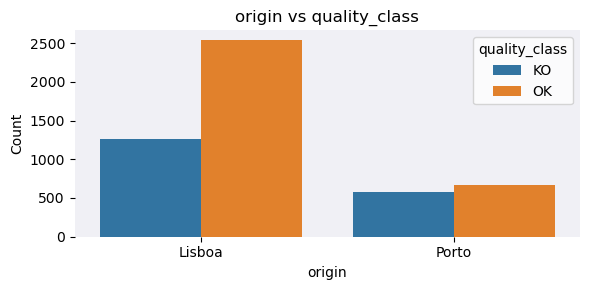

In [16]:
# Percentage of each quality_class per origin
learn['origin'] = learn['origin'].str.strip().str.title()
distribution = pd.crosstab(learn['origin'], learn['quality_class'], normalize='index') * 100
display(distribution.round(2))

# Distribution of Quality_class by Origin
plt.figure(figsize=(6, 3))
sns.countplot(x='origin', data=learn, hue='quality_class', palette=["#1F77B4", "#FF7F0E"])
plt.title('origin vs quality_class', fontsize=12)
plt.xlabel('origin')
plt.ylabel('Count')

plt.gca().set_facecolor('#f0f0f5')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <ul>
    <li>
      <strong><code>quality_class</code>:</strong>
      <ul style="margin-top:5px;">
        <li>The quality of the pastry, classified as <code>OK</code> or <code>KO</code>. This is the variable we aim to predict with our model;</li>
        <li><strong>Distribution:</strong> After examining the dataset:
          <ul>
            <li><code>OK</code>: ~63.51%</li>
            <li><code>KO</code>: ~36.49%</li>
          </ul>
        </li>
        <li><strong>Encoding:</strong> We will encode <code>quality_class</code> as a binary variable, e.g., <code>OK=1</code> and <code>KO=0</code>, so that it can be used in machine learning models;</li>
        <li><strong>Handling slight imbalance:</strong> To ensure fair model performance across both classes, we will adopt light interventions, such as:
          <ul>
            <li>Using balanced metrics (e.g., precision, recall, and F1-score) instead of relying only on accuracy;</li>
            <li>Using <code>stratify=y</code> when splitting the dataset to maintain the class distribution in both training and test sets.</li>
          </ul>
          These steps are sufficient to address the small imbalance and help the model perform well on both classes.
        </li>
      </ul>
    </li>
  </ul>
</div>


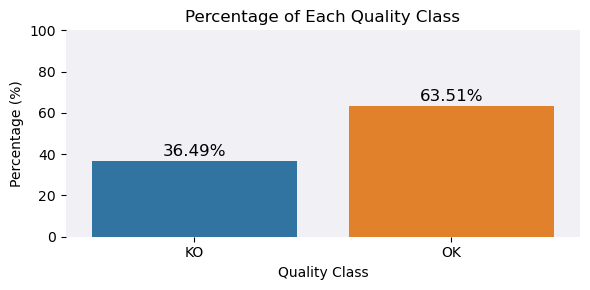

In [17]:
# Percentage of each quality_class
percent_df = learn['quality_class'].value_counts(normalize=True) * 100
percent_df = percent_df.reindex(['KO', 'OK']).dropna()
percent_df = percent_df.reset_index()
percent_df.columns = ['quality_class', 'percentage']

# Plot
plt.figure(figsize=(6, 3))
sns.barplot(
    data=percent_df,
    x='quality_class',
    y='percentage',
    hue='quality_class',         # assign hue to avoid FutureWarning
    palette=["#1F77B4", "#FF7F0E"],
    dodge=False,
    legend=False                  # disable legend directly
)
plt.title('Percentage of Each Quality Class', fontsize=12)
plt.xlabel('Quality Class')
plt.ylabel('Percentage (%)')

plt.gca().set_facecolor('#f0f0f5')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.ylim(0, 100)

for i, row in percent_df.iterrows():
    plt.text(i, row['percentage'] + 1, f"{row['percentage']:.2f}%", 
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

<br>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong><font color='#E89C63'>2. Numerical Columns</font></strong> <a class="anchor" id="P14"></a>
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <ul>
    <li>
      <strong><code>id</code>:</strong><br>
      Will be used as the index for the training (<code>learn</code>) and prediction (<code>predict</code>) datasets, ensuring each record has a unique identifier and maintaining consistent alignment for predictions.
    </li>
    <br>
    <li>
      <strong><code>vanilla_extract</code> (ml/L):</strong><br>
      Measures a concentration, which is a different type of quantity. Since it is not directly comparable to mass fractions, it does not need to share the same unit as <code>salt_ratio</code> or <code>sugar_content</code>. It only needs to be consistent within itself across datasets.
    </li>
    <br>
    <li>
      <strong><code>salt_ratio</code> (g/kg) and <code>sugar_content</code> (g/100g):</strong>
      <ul style="margin-top:5px; margin-left:20px;">
        <li><strong>Conversion:</strong> We will convert <code>salt_ratio</code> to the same unit as <code>sugar_content</code> by dividing all values by 10;</li>
        <li><strong>Errors in <code>sugar_content</code>:</strong> The approach we chose was to divide by 10, because even if we apply the IQR method for outliers later in Notebook 2, these incorrect values would still remain. For reference, we have attached graphs below to show the quantity of errors, highlighting cases where sugar content exceeds 100 g per 100 g of product.</li>
      </ul>
    </li>
  </ul>
</div>


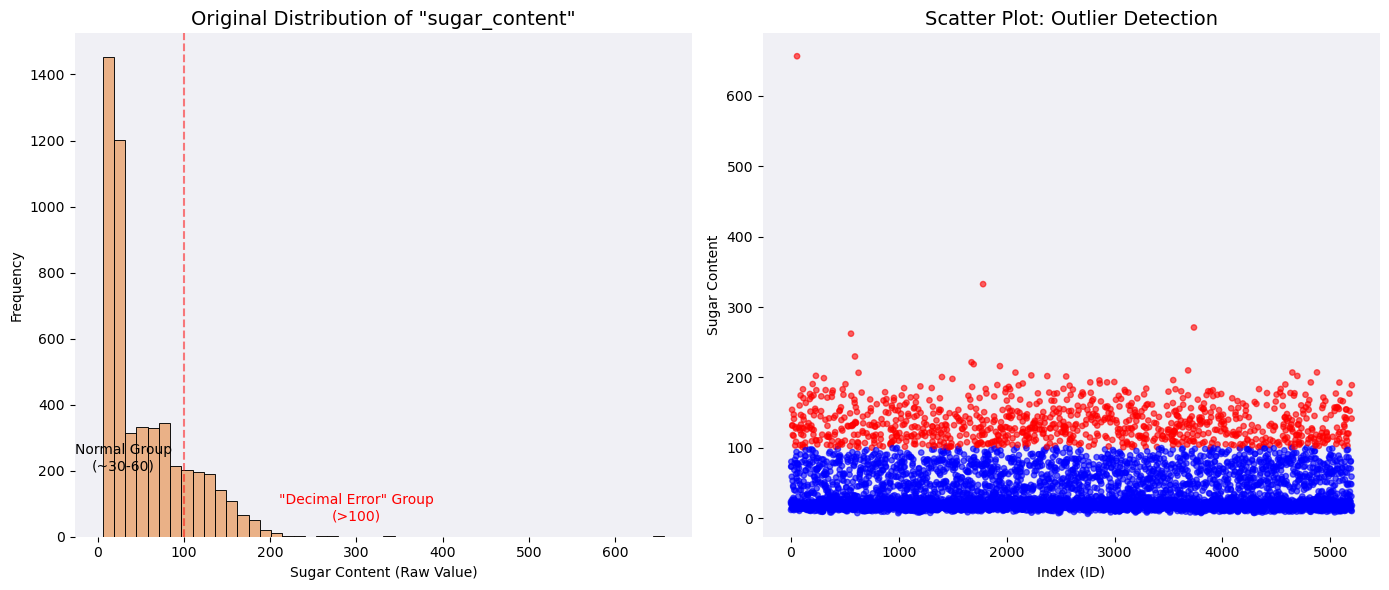

In [18]:
plt.figure(figsize=(14, 6))

# GRAPH 1: Original Distribution 
plt.subplot(1, 2, 1)
sns.histplot(learn['sugar_content'], bins=50, color='#E89C63', kde=False)
plt.title('Original Distribution of "sugar_content"', fontsize=14)
plt.xlabel('Sugar Content (Raw Value)')
plt.ylabel('Frequency')
plt.axvline(x=100, color='red', linestyle='--', alpha=0.5)
plt.text(30, 200, 'Normal Group\n(~30-60)', color='black', ha='center')
plt.text(300, 50, '"Decimal Error" Group\n(>100)', color='red', ha='center')
ax1 = plt.gca()
ax1.set_facecolor('#f0f0f5')

ax1.grid(False)
for spine in ax1.spines.values():
    spine.set_visible(False)

# GRAPH 2: Scatter Plot 
plt.subplot(1, 2, 2)
colors = ['red' if x > 100 else 'blue' for x in learn['sugar_content']]
plt.scatter(learn.index, learn['sugar_content'], c=colors, alpha=0.6, s=15)
plt.title('Scatter Plot: Outlier Detection', fontsize=14)
plt.xlabel('Index (ID)')
plt.ylabel('Sugar Content')
ax2 = plt.gca()
ax2.set_facecolor('#f0f0f5')
ax2.grid(False)

for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong><font color='#E89C63'>3. Irrelevant Columns</font></strong> <a class="anchor" id="P15"></a>
</div>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Columns that are completely empty or contain no meaningful information do not contribute to the model and can introduce noise. Therefore, they should be removed from both <code>learn</code> and <code>predict</code> to ensure the datasets have the same structure, the model uses only relevant features, preprocessing works correctly, and predictions are reliable.
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <ul>
    <li>
      <strong><code>notes_baker</code>:</strong><br>
      It's completely empty in both datasets, therefore, we can drop it.
    </li>
            <br>
    <li>
      <strong><code>pastry_type</code>:</strong><br>
      Can also be dropped, because it does not help the model.
      <ul style="margin-top:5px; margin-bottom:5px;">
        <li>Our focus is only on <strong>evaluating the quality of pastéis de nata</strong>;</li>
        <li>Out of 5,200 rows, <strong>1,789 rows have missing <code>pastry_type</code> values</strong>;</li>
        <li>We <strong>cannot remove these rows</strong> in <code>learn</code>, because the model would not know how to handle them in <code>predict</code>;</li>
        <li>The prediction dataset also contains missing values in <code>pastry_type</code>, so we <strong>cannot drop any rows</strong>;</li>
        <li>We also <strong>cannot treat missing values as a separate category</strong>, because without knowing if the pastry is actually a pastel de nata, we cannot properly assess its quality;</li>
        <li>Since all rows correspond to <strong>Pastel De Nata</strong>, the <code>pastry_type</code> column effectively has the same value for every row and can be safely removed.</li>
      </ul>
    </li>
  </ul>
</div>


<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong><font color='#E89C63'>4. Conclusion</font></strong> <a class="anchor" id="P16"></a>
</div>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
The datasets are suitable for classification, but require data cleaning, text normalization, imputation of missing values, and feature scaling before model training. Outliers in <code>learn</code> should also be checked and handled appropriately.
</div>
<br>

---
#### <strong> <font color='#E89C63'> Analysis: Media, Median and Outliers  </font> <a class="anchor" id="P17"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
We will explore <strong>outliers in the <code>learn</code> dataset more deeply</strong>. The <code>predict</code> dataset is not analyzed here, as it is meant for <strong>model evaluation only</strong>.
</div>
<br>


**2.3.** Use the `learn.describe().T` method to quickly obtain summary statistics (count, mean, standard deviation, min, max, and quartiles) for all numeric features, allowing us to detect outliers, and scale differences between variables. 

Create boxplots for all numeric features to visually inspect their distributions and identify potential outliers before preprocessing.

In [19]:
learn.describe().drop('notes_baker',axis=1).T

,count,mean,std,min,25%,50%,75%,max
ambient_humidity,5182.0,59.980316,11.616151,40.00,50.00,60.00,70.000,80.00
baking_duration,5199.0,26.979804,8.320079,14.00,21.00,25.00,30.000,89.00
cooling_period,5199.0,31.817850,14.427143,0.00,25.00,31.00,39.000,105.00
cream_fat_content,5176.0,98.413060,1.997350,91.90,97.10,98.40,99.800,107.30
egg_temperature,5176.0,70.812403,35.439831,12.00,44.00,67.00,92.000,575.00
egg_yolk_count,5176.0,10.498068,1.257709,8.00,10.00,10.00,11.000,15.00
final_temperature,5175.0,223.577198,85.258779,31.00,164.00,226.00,284.000,722.00
lemon_zest_ph,5174.0,3.218902,0.165909,2.70,3.10,3.20,3.300,4.00
oven_temperature,5179.0,223.541031,84.482034,58.00,166.00,227.00,283.000,713.00
preheating_time,5181.0,216.413241,39.533116,114.00,192.00,209.00,231.000,499.00


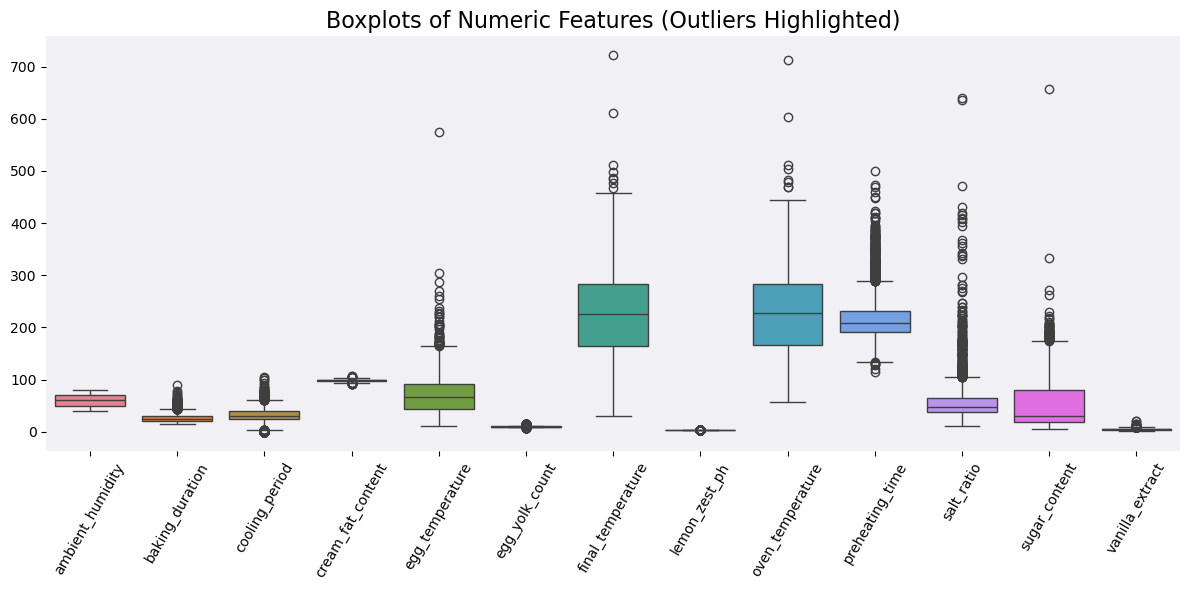

In [20]:
numeric_features = learn.select_dtypes(include='number').drop('notes_baker', axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_features)
plt.xticks(rotation=60)
plt.title("Boxplots of Numeric Features (Outliers Highlighted)", fontsize=16)
plt.gca().set_facecolor('#f0f0f5')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<ul>
  <li>Most variables (<code>ambient_humidity</code>, <code>cream_fat_content</code>, <code>lemon_zest_ph</code>, <code>egg_yolk_count</code>, <code>vanilla_extract</code>) have <strong>mean ≈ median</strong>, indicating <strong>symmetric distributions</strong> and low variability;</li>
    <br>
  <li>Some variables (<code>baking_duration</code>, <code>cooling_period</code>, <code>preheating_time</code>) have <strong>mean slightly higher than median</strong>, suggesting <strong>slightly positively skewed</strong>;</li>
    <br>
  <li>Variables like <code>egg_temperature</code>, <code>final_temperature</code>, <code>oven_temperature</code>, <code>salt_ratio</code>, and <code>sugar_content</code> have <strong>extremely high maximum values</strong> compared to their mean and median, clearly indicating <strong>outliers</strong>;</li>
    <br>
  <li><strong>Median</strong> appears more representative than mean for skewed variables, as the <strong>mean is pulled up by extreme values</strong>. Therefore, the <strong>median is a better choice than mean</strong> for imputing missing values or handling outliers in numeric variables.</li>
</ul>
</div>
<br>

<br>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong><font color='#E89C63'> Multivariate Outlier Detection: Baking Duration vs. Oven Temperature</font></strong> <a class="anchor" id="P18"></a>
</div>
</div>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
While univariate boxplots are useful for identifying <strong>extreme values</strong> in individual variables, they do not capture <strong>interactions between process parameters</strong>. To investigate potential <strong>multivariate outliers</strong>, we analyzed the joint behaviour of <code>baking duration</code> and <code>oven temperature</code> using a scatter plot. This visualization reveals how certain combinations of these variables fall outside the typical operating window for successful batches. In particular, it allows us to identify regions where failures occur not due to extreme values in a single variable, but due to <strong>specific parameter combinations</strong>, which would remain undetected in univariate boxplots.
</div>


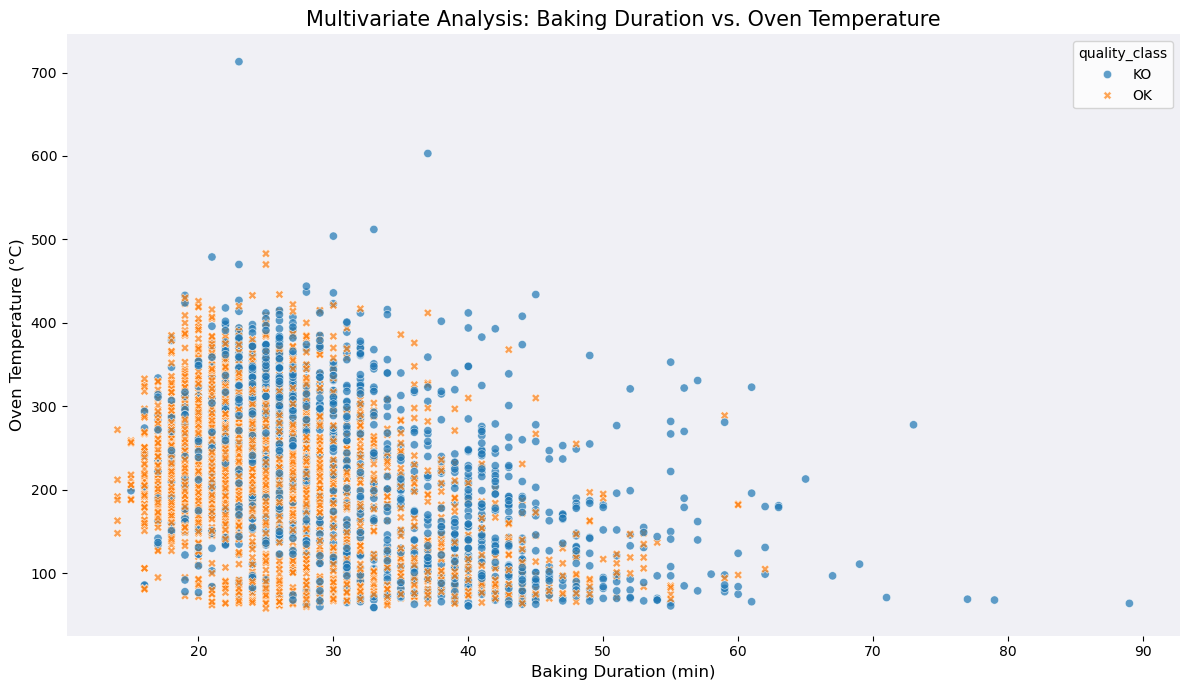

In [21]:
# Set figure size
plt.figure(figsize=(12, 7))

# Create the scatter plot
sns.scatterplot(
    data=learn, 
    x='baking_duration', 
    y='oven_temperature', 
    hue='quality_class',        
    style='quality_class',      
    alpha=0.7,                 
    palette={'OK': '#FF7F0E', 'KO': '#1F77B4'} 
)

plt.title('Multivariate Analysis: Baking Duration vs. Oven Temperature', fontsize=15)
plt.xlabel('Baking Duration (min)', fontsize=12)
plt.ylabel('Oven Temperature (°C)', fontsize=12)
plt.gca().set_facecolor('#f0f0f5')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

</div>
<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The plot reveals a <strong>distinct operating window</strong> for <code>'OK'</code> pastries. Notably, the region where <code>Baking Duration &gt; 50 minutes</code> is populated almost exclusively by <code>'KO'</code> samples. This indicates a <strong>specific failure mode</strong>, likely <em>low and slow</em> cooking that results in dried-out pastry rather than burning. Based on this clear separation, we will engineer a new feature, <code>is_burnt</code>, in the next Notebooks, to flag any production exceeding this time threshold.
</div>


<br>

---
#### <strong> <font color='#E89C63'> Analysis: Skewed Distributions </font> <a class="anchor" id="P19"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
To better understand the distribution of numeric features in the dataset, we will <strong>plot histograms and density plots</strong> for each column. This allows us to visually inspect <strong>skewness, spread, and potential outliers</strong>.
</div>
<br>

**2.4.** Explore the distribution of the numerical features in the dataset.

Many machine learning algorithms such as Linear Regression and Logistic Regression, assume data is roughly normally distributed. Skewed data break these assumptions, leading to biased predictions.

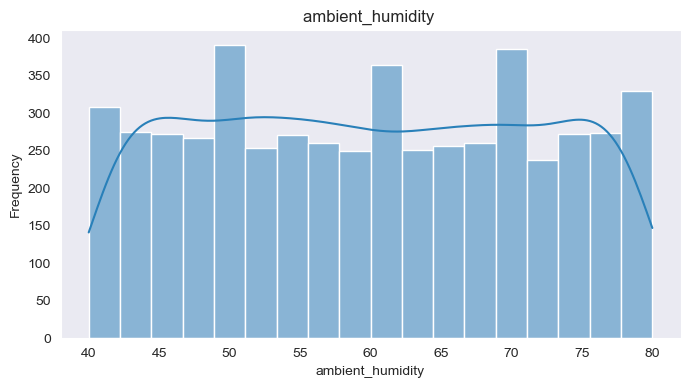

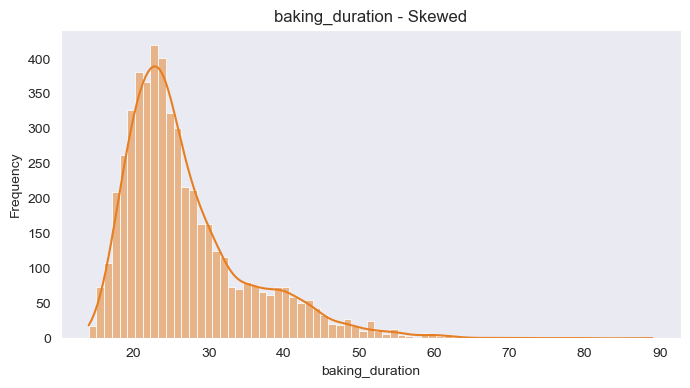

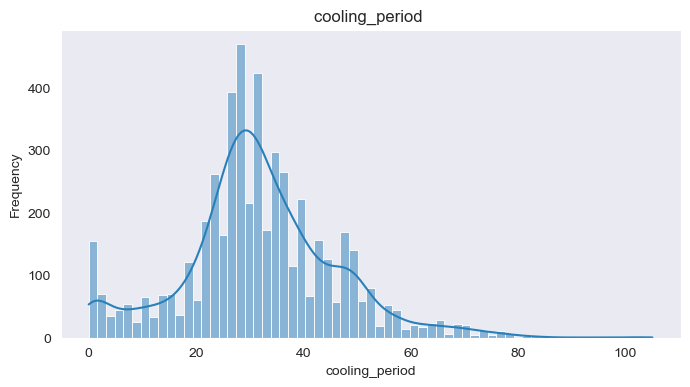

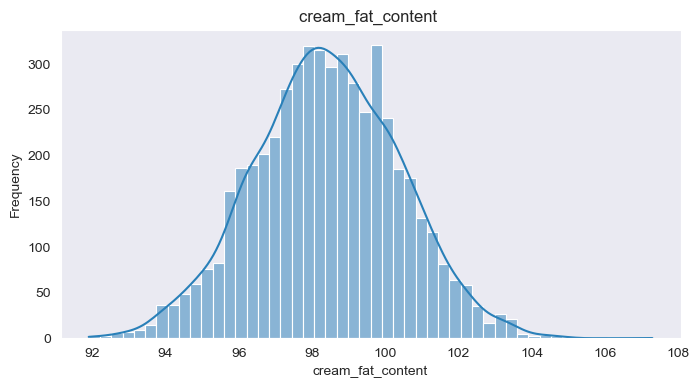

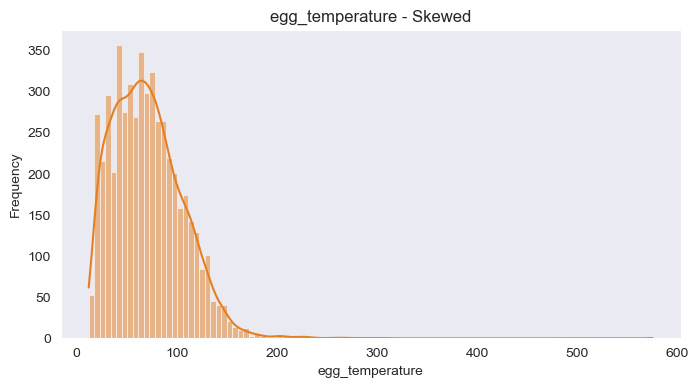

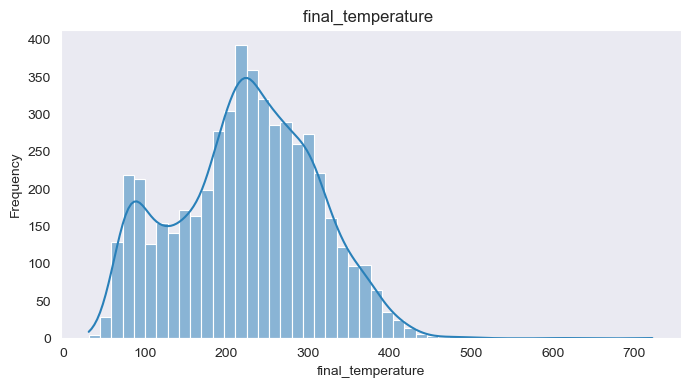

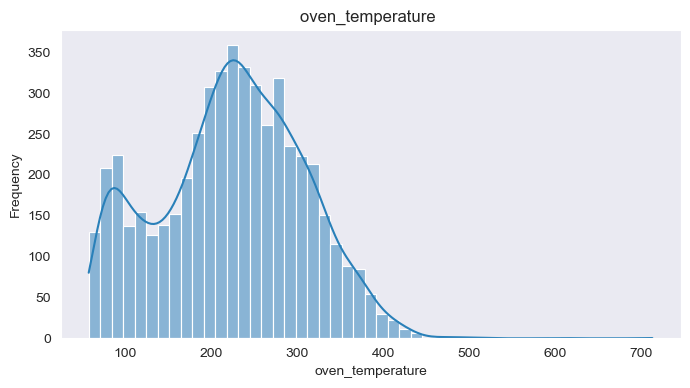

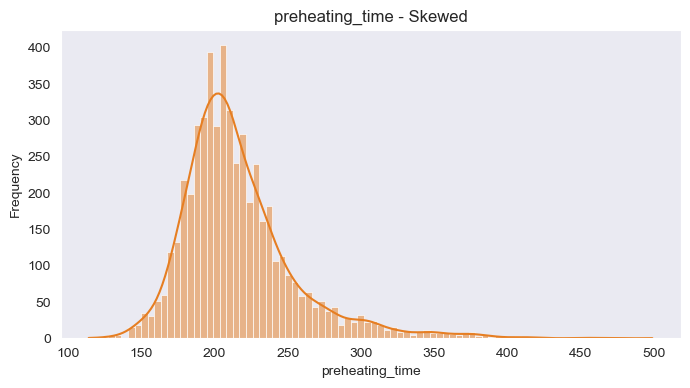

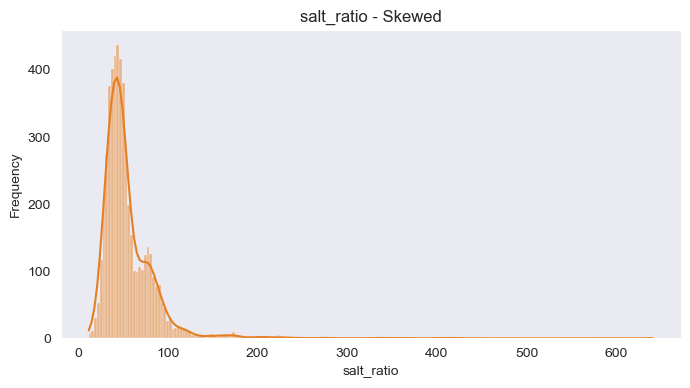

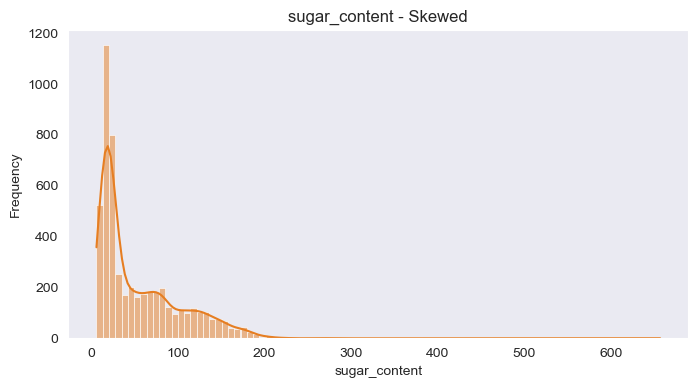

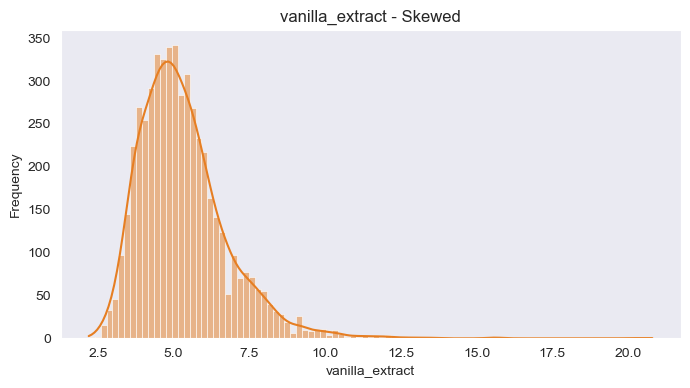

In [22]:
def plot_skewed_columns_learn(threshold=1.0):
    global learn  
    
    # Columns to exclude from skew analysis. These columns have a smaller range of values.
    exclude_cols = ['egg_yolk_count', 'lemon_zest_ph', 'pastry_type', 'notes_baker', 'origin', 'quality_class']
    
    # Select only numeric columns, excluding the ones specified
    num_cols = learn.select_dtypes(include=np.number).columns.difference(exclude_cols)
    
    df_c = learn.copy()
    
    skew_vals = df_c[num_cols].skew()
    
    skewed_cols = skew_vals[skew_vals > threshold].index.tolist()
    
    sns.set_style('dark')
    
    for col in num_cols:
        plt.figure(figsize=(8,4))
        # Use orange color if column is skewed above the threshold, blue otherwise
        color = "#E67E22" if col in skewed_cols else "#2980B9"
        sns.histplot(df_c[col], kde=True, color=color)
        plt.title(f'{col} {"- Skewed" if col in skewed_cols else ""}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
    
    return df_c

df_learn = plot_skewed_columns_learn(threshold=1.0)

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
The distributions show that several continuous variables of the <code>learn</code> dataset are highly skewed, including:
<ul>
  <li><code>baking_duration</code>;</li>
  <li><code>egg_temperature</code>;</li>
  <li><code>preheating_time</code>;</li>
  <li><code>salt_ratio</code>;</li>
  <li><code>sugar_content</code>;</li>
  <li><code>vanilla_extract</code>.</li>
</ul>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
To identify these columns, we calculated the <strong>skewness coefficient (skew)</strong>, which measures whether the data is tilted to the right or to the left. In pandas, this is done automatically, but the idea is:

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
<div style="text-align:center;">
$$
\text{skew} = \frac{\text{mean} - \text{median}}{\text{standard deviation}}
$$
</div>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
We consider a column skewed only if the <strong>absolute value of skew</strong> is greater than 1. We chose the value 1 as a cutoff point because it indicates significant asymmetry: values below 1 are considered mild and generally do not affect model performance, while values above 1 show a meaningful distortion in the distribution that can influence the results.

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
In Notebook 2, we will test two ways of using these variables:
<ul>
  <li><strong>Without transformation</strong>, using the original data;</li>
  <li><strong>With log-transformation</strong>, to reduce extreme values and make the distribution more balanced.</li>
</ul>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
Categorical variables, such as <code>origin</code> and <code>quality_class</code>, are not affected by skewness and do not require transformation. This allows us to focus only on the continuous variables that actually exhibit asymmetry.
</div>
<br>

---
#### <strong> <font color='#E89C63'> Handling: Missing Values and Outliers </font> <a class="anchor" id="P20"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
In Notebook 2, we will test different preprocessing strategies and model configurations to evaluate their impact on predictive performance. All preprocessing steps are <strong>learned from the training data after splitting</strong> and then consistently applied to the test data to avoid information leakage.
</div>
<br>

<div style="font-size:15px; line-height:1.5; margin-bottom:10px;">
  <strong>Median as Reference Statistic</strong>
  <ul>
    <li>Before handling missing values or outliers, we will rely on the <strong>median</strong> as a robust measure of central tendency;</li>
    <li>The median is preferred over the mean because it is <strong>less sensitive to skewness and extreme values</strong>, making it suitable for imputing missing values and replacing outliers.</li>
  </ul>
<br>
  <strong> <font color='#E89C63'>1. Outliers</font></strong> <a class="anchor" id="P20"></a>
  <ul>
      <li><strong>Why handle first:</strong> Outliers are treated before missing values or scaling to <strong>prevent extreme values from biasing imputations and transformations</strong>, ensuring that the subsequent steps (like median imputation or feature scaling) are robust and accurate.</li>
    <li>Outliers in the dataset are identified using descriptive statistics derived from the <strong>training set</strong>. Methodology:
      <ol>
        <li><strong>Compute Descriptive Metrics:</strong>
          <ul>
            <li>1st Quartile (Q1);</li>
            <li>3rd Quartile (Q3);</li>
            <li>Interquartile Range (IQR) = Q3 - Q1.</li>
          </ul>
        </li>
        <li><strong>Identify Outliers:</strong> A value is an outlier if:
          <ul>
            <li>value &lt; Q1 - 1.5 * IQR;</li>
            <li>value &gt; Q3 + 1.5 * IQR.</li>
          </ul>
        </li>
      </ol>
    </li>
    <li>Strategies to handle outliers:
      <ul>
        <li><strong>Median-based Replacement:</strong> Replace values outside a specified range with the median computed from the training set;</li>
        <li><strong>IQR-based Clipping:</strong> Cap extreme values to [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] using the <code>iqr_clip_num</code> function;</li>
        <li><strong>None:</strong> Leave outliers untreated to evaluate model sensitivity.</li>
      </ul>
    </li>
  </ul>
<br>
  <strong> <font color='#E89C63'>2. Missing Values</font></strong> <a class="anchor" id="P20"></a>
  <ul>
    <li>Imputation methods evaluated:
      <ul>
        <li><strong>Median Imputation:</strong> Replace missing values with the median computed from the training set;</li>
        <li><strong>KNN Imputation:</strong> Estimate missing values using K-Nearest Neighbors based on similarity to other samples in the training set, using the <strong>default k=5 neighbors</strong>. This balances smoothing and sensitivity to local patterns without extensive hyperparameter tuning.</li>
      </ul>
    </li>
  </ul>
<br>
  <strong> <font color='#E89C63'>3. Log Transformation</font> </strong> <a class="anchor" id="P20"></a>
  <ul>
  <li>To reduce skewness and minimize the impact of extreme values, <strong>models will be tested both with and without log transformation</strong> on skewed features;</li>
  <li>Only features with <strong>skewness &gt; 1</strong> (threshold = 1) will be transformed;</li>
  <li>Transformation parameters are learned from the training set and applied to the test set.</li>
</ul>
<br>
    <strong> <font color='#E89C63'>4. Feature Scaling</font> </strong> <a class="anchor" id="P20"></a>
  <ul>
    <li>For models sensitive to feature magnitude (e.g., Logistic Regression, KNN), we will evaluate:
      <ul>
        <li><strong>Standard Scaler:</strong> Transforms features to zero mean and unit variance;</li>
        <li><strong>Robust Scaler:</strong> Uses median and IQR, robust to outliers;</li>
        <li><strong>MinMax Scaler:</strong> Rescales features to a fixed range [0,1].</li>
      </ul>
    </li>
    <li>All scalers are <strong>fitted on the training data and applied to the test set</strong> to avoid data leakage.</li>
  </ul>
<br>
  <strong> <font color='#E89C63'>5. Preprocessing Evaluation</font> </strong> <a class="anchor" id="P20"></a>
<ul>
  <li>We will test all possible combinations of preprocessing strategies:
    <ul>
      <li>Outlier handling methods;</li>
      <li>Missing value imputation methods;</li>
      <li>Log transformation applied to skewed columns (skewness &gt; 1);</li>
      <li>Feature scaling.</li>
    </ul>
  </li>
  <li>Models evaluated:<br>
We restricted this exhaustive preprocessing search to <strong>three baseline models</strong> because they represent <strong>distinct algorithmic families</strong>: <strong>linear (Logistic Regression)</strong>, <strong>distance-based (KNN)</strong>, and <strong>tree-based (Random Forest)</strong>.</li>By identifying a strategy that performs <strong>consistently well across diverse model types</strong>, we can define a <strong>robust, general-purpose preprocessing pipeline</strong>, ensuring <strong>data consistency</strong> and avoiding the <strong>high computational cost</strong> of repeating a full search for <strong>computationally intensive ensemble models</strong> (such as <strong>Gradient Boosting</strong> or <strong>Stacking</strong>) later in the analysis.</li>
  <li>For each model, we will identify the <strong>top 5 preprocessing combinations</strong> based on performance metrics (<strong>Accuracy</strong> and <strong>F1_macro</strong>);</li>
  <li>By analyzing which preprocessing methods consistently appear in the top 5 across different models, we can determine the <strong>robust strategies</strong> for handling outliers, missing values, skewed columns, and scaling to process the dataset effectively.</li>
</ul>
</br>

---
#### <strong> <font color='#E89C63'>Analysis: Correlations of Numerical Features with the Target Variable </font> <a class="anchor" id="21"></a> </strong>
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
In this section, we examine <strong>how numerical features are correlated with the target</strong>. This helps identify <strong>which variables are most strongly associated with the target</strong> and highlights opportunities to <strong>create new features</strong> from those that meaningfully contribute to the prediction.
</div>
<br>


**2.5.** Use the method `corr()` to examine the relationships between all numerical features with the target `quality_class` and discuss any interesting patterns or strong associations you observe.

Since most of our numerical features are skewed and may not follow a normal distribution, we use Spearman correlation instead of Pearson.

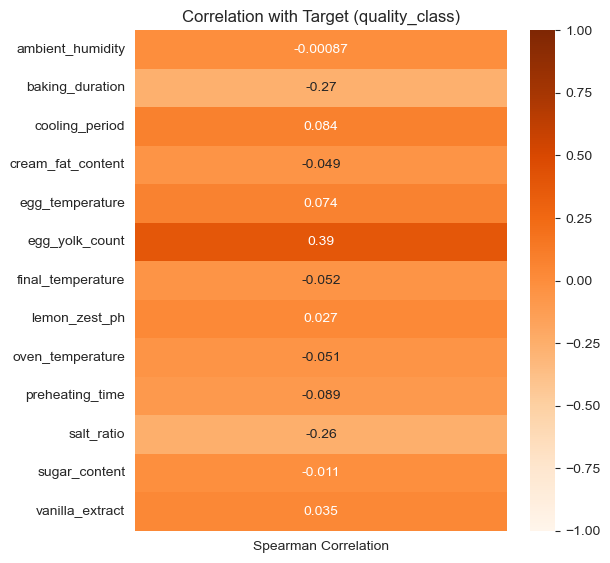

In [23]:
# Convert the target variable to 0 and 1
learn['quality_class_enc'] = learn['quality_class'].map({'KO': 0, 'OK': 1})

# Select numerical features (excluding 'notes_baker' and 'quality_class_num')
numeric_features = learn.select_dtypes(include='number').drop(['notes_baker', 'quality_class_enc'], axis=1)

# Calculate Spearman correlation with the target
target_corr = numeric_features.corrwith(learn['quality_class_enc'], method='spearman').to_frame(name='Spearman Correlation')

# Plot the heatmap of correlations with the target
plt.figure(figsize=(6, len(target_corr)*0.5))
sns.heatmap(target_corr, annot=True, cmap='Oranges', vmin=-1, vmax=1)
plt.title('Correlation with Target (quality_class)')
plt.show()

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
Spearman analysis shows that <code>egg_yolk_count</code> has the <strong>highest correlation with the target variable</strong> <code>quality_class</code> (~0.39), indicating a moderate positive relationship.  
</div>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
In contrast, <code>ambient_humidity</code> has an <strong>almost zero correlation<strong> (~−0.00087), suggesting little to no influence on quality.  
</div>

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
For creating new features, we will focus on variables with significant correlations with the target, such as <code>egg_yolk_count</code>, <code>baking_duration</code>, <code>salt_ratio</code>, and others, combining them to generate more informative features that can improve model performance.
</div>
<br>


---
#### <strong> <font color='#E89C63'>Analysis: Correlation Analysis of Numerical Features (Excluding Target) </font> <a class="anchor" id="P22"></a> 
---
<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
In this section, we explore the <strong>relationships between numerical features</strong> in the dataset by examining their <strong>correlations</strong>. This helps identify <strong>which variables are most strongly related to each other</strong>.
</div>
<br>


**2.6.** Use the method `corr()` to examine the relationships between all numerical features without the target and discuss any interesting patterns or strong associations you observe.

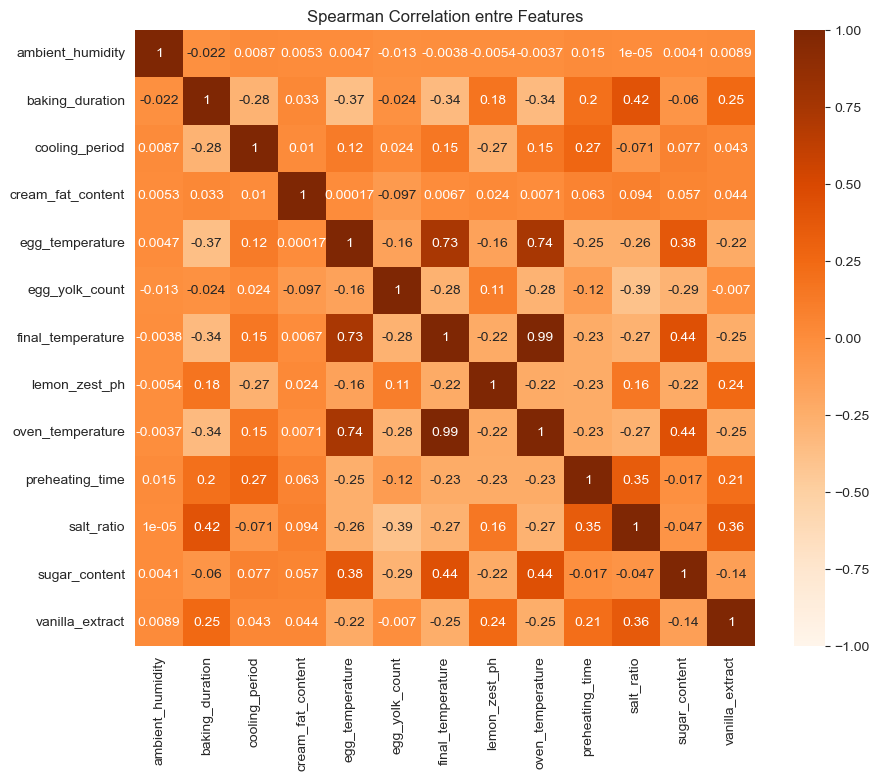

In [24]:
numeric_features = learn.select_dtypes(include='number').drop(['notes_baker', 'quality_class_enc'], axis=1)

corr_matrix = numeric_features.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', vmin=-1, vmax=1)
plt.title('Spearman Correlation entre Features')
plt.show()

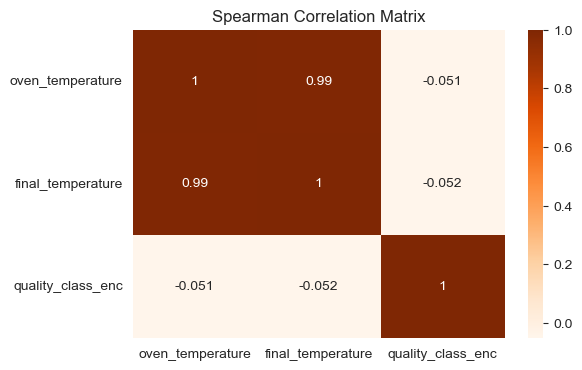

In [25]:
temp_learn = learn[['oven_temperature', 'final_temperature', 'quality_class']].copy()

temp_learn['quality_class_enc'] = temp_learn['quality_class'].map({'OK': 1, 'KO': 0})

corr = temp_learn[['oven_temperature', 'final_temperature', 'quality_class_enc']].corr(method='spearman')

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Oranges')
plt.title('Spearman Correlation Matrix')
plt.show()

<div style="font-size:15px; line-height:1.4; margin-bottom:10px;">
The correlation matrix shows that some numeric features are highly correlated, such as <code>oven_temperature</code> and <code>final_temperature</code>. Since these variables are redundant and have similar correlations with the target, <strong>it will likely be recommended to remove one of them during feature selection</strong>, in Notebook 3.<br><br>
Most other features have low to moderate correlation, indicating that they provide independent information.
</div>
<br>
